# Modeling — Churn Prediction

Implementación completa siguiendo el plan de `modeling.md`.  
Dataset: `data/warehouse/train.csv` — 58.049 filas, 22 features + target `churn` (8.8% positivos).

Modelos entrenados: **Logistic Regression · Random Forest · XGBoost · LightGBM**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    f1_score,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

%matplotlib inline
sns.set_theme(style="whitegrid")


## 1. Carga del dataset

In [2]:
df = pd.read_csv("data/warehouse/train_claude.csv", parse_dates=['sales_date', 'base_date'])

print(f"Shape: {df.shape}")
print(f"Clientes únicos: {df['customer_id'].nunique():,}")
print(f"Churn rate: {df['churn'].mean():.1%}")
print(f"Positivos: {df['churn'].sum():,}  |  Negativos: {(df['churn']==0).sum():,}")
df.head(3)

Shape: (58049, 41)
Clientes únicos: 44,053
Churn rate: 8.8%
Positivos: 5,093  |  Negativos: 52,956


,code,customer_id,sales_date,base_date,pvp,margen_relativo,margen_eur_negativo,coste_venta_no_impuestos,forma_pago,dias_desde_compra,...,genero,renta_media_estimada,renta_desconocida,status_social,modelo,equipamiento,es_electrico,kw,zona,churn
0,ID10629,1,2023-01-02,2023-12-31,18579.0,0.085946,0,1529.0,Contado,363,...,M,25641.0,0,H,B,Low,0,74.0,CENTRO,0
1,ID954,7,2019-07-24,2023-12-31,15195.0,0.068886,0,864.0,Otros,1621,...,F,0.0,1,Sin_dato,A,High,0,64.0,CENTRO,0
2,ID50746,10,2022-04-12,2023-12-31,30330.0,0.218366,0,1034.0,Otros,628,...,M,0.0,1,Sin_dato,I,Mid,0,106.0,CENTRO,0


## Distribuciones: churn vs no churn

Análisis visual de las features más discriminantes antes de entrenar los modelos.  
Línea roja discontinua = tasa de churn global (8.8%).

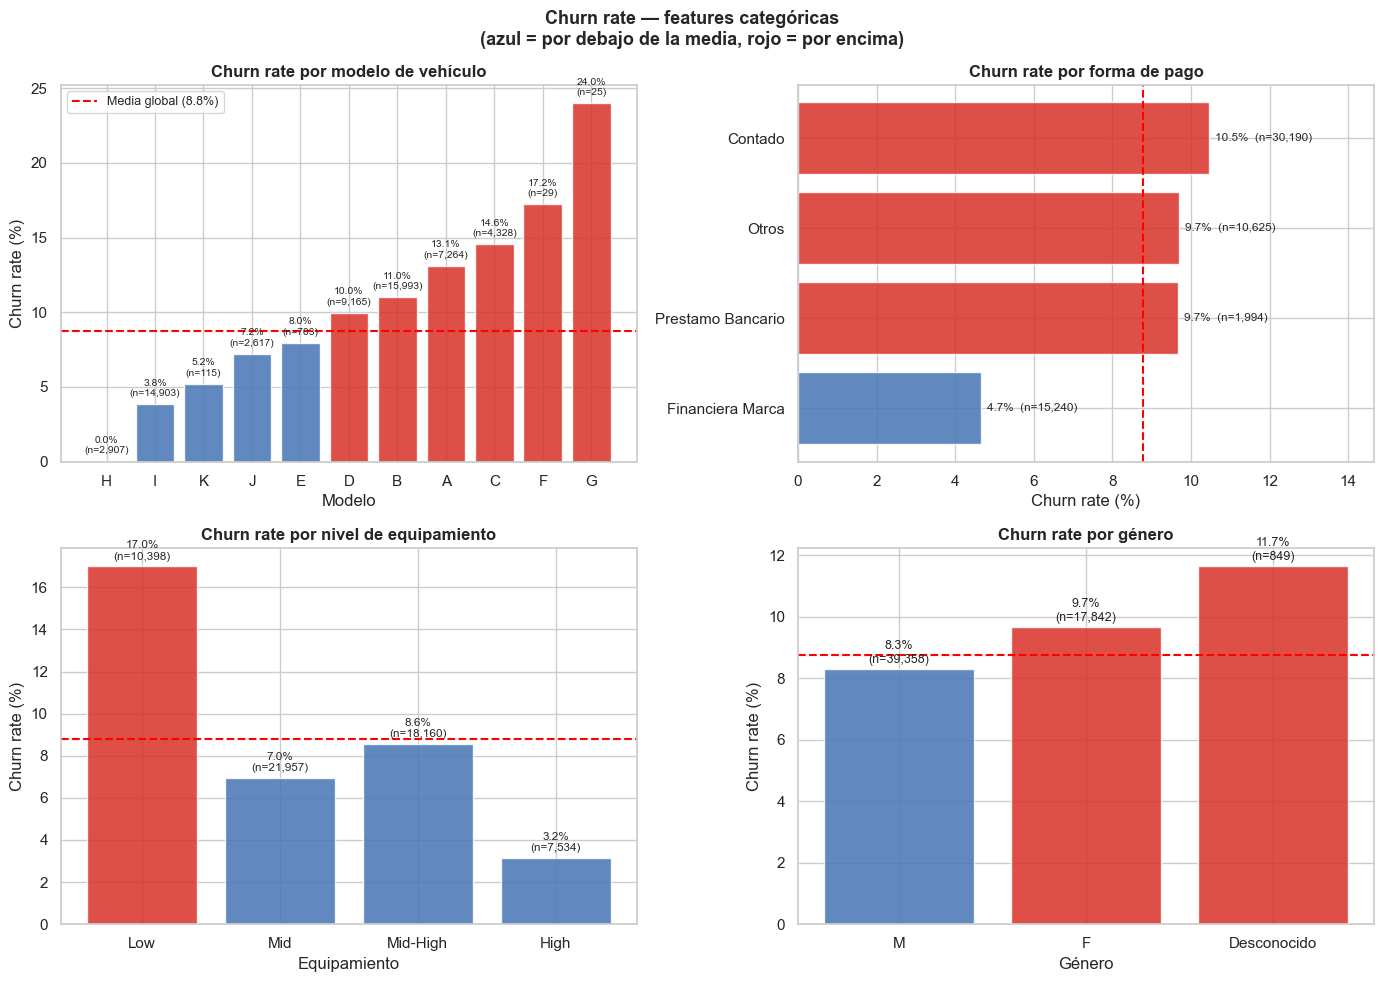

In [3]:
# ── Features categóricas ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
global_rate = df['churn'].mean() * 100

# modelo
ax = axes[0, 0]
cr = df.groupby('modelo')['churn'].agg(['mean', 'count']).sort_values('mean')
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.bar(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(global_rate, color='red', linestyle='--', linewidth=1.5, label=f'Media global ({global_rate:.1f}%)')
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=7.5)
ax.set_title('Churn rate por modelo de vehículo', fontweight='bold')
ax.set_xlabel('Modelo'); ax.set_ylabel('Churn rate (%)')
ax.legend(fontsize=9)

# forma_pago
ax = axes[0, 1]
cr = df.groupby('forma_pago')['churn'].agg(['mean', 'count']).sort_values('mean')
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.barh(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(global_rate, color='red', linestyle='--', linewidth=1.5)
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:.1%}  (n={int(row["count"]):,})', va='center', fontsize=8.5)
ax.set_xlim(0, cr['mean'].max() * 100 * 1.4)
ax.set_title('Churn rate por forma de pago', fontweight='bold')
ax.set_xlabel('Churn rate (%)')

# equipamiento
ax = axes[1, 0]
eq_order = ['Low', 'Mid', 'Mid-High', 'High']
cr = df.groupby('equipamiento')['churn'].agg(['mean', 'count']).reindex(eq_order)
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.bar(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(global_rate, color='red', linestyle='--', linewidth=1.5)
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=8.5)
ax.set_title('Churn rate por nivel de equipamiento', fontweight='bold')
ax.set_xlabel('Equipamiento'); ax.set_ylabel('Churn rate (%)')

# genero
ax = axes[1, 1]
cr = df.groupby('genero')['churn'].agg(['mean', 'count']).sort_values('mean')
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr['mean']]
bars = ax.bar(cr.index, cr['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(global_rate, color='red', linestyle='--', linewidth=1.5)
for bar, (_, row) in zip(bars, cr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=9)
ax.set_title('Churn rate por género', fontweight='bold')
ax.set_xlabel('Género'); ax.set_ylabel('Churn rate (%)')

plt.suptitle('Churn rate — features categóricas\n(azul = por debajo de la media, rojo = por encima)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

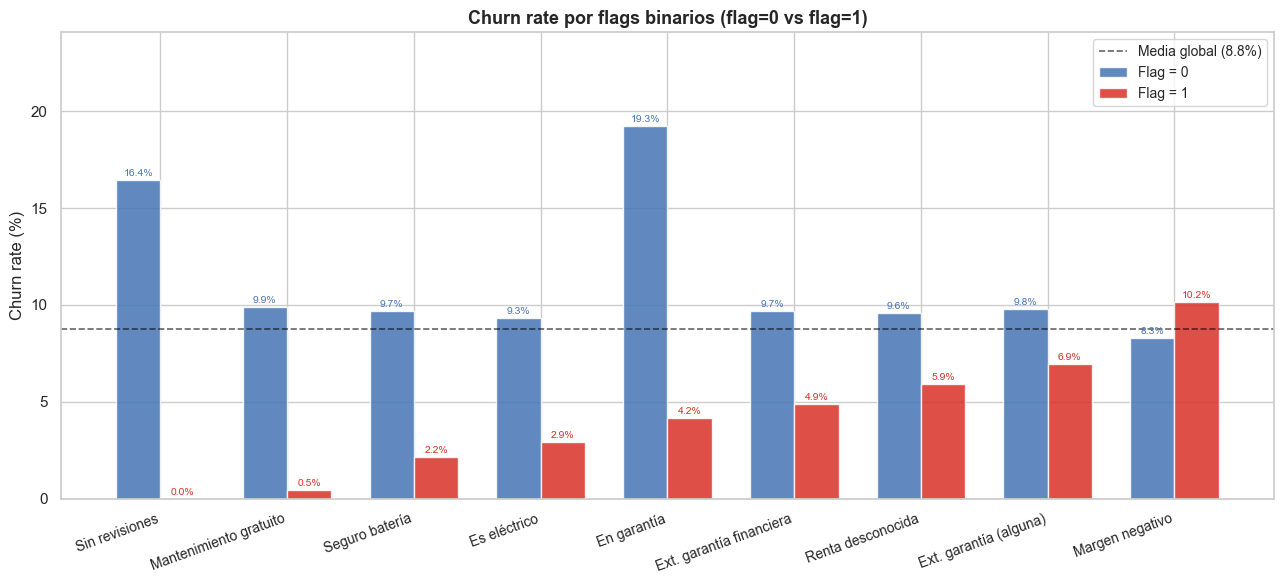

In [4]:
# ── Flags binarios: churn rate cuando flag=1 vs flag=0 ───────────────────────
flag_meta = {
    'en_garantia':              'En garantía',
    'mantenimiento_gratuito':   'Mantenimiento gratuito',
    'seguro_bateria_largo_plazo': 'Seguro batería',
    'ext_garantia_financiera':  'Ext. garantía financiera',
    'ext_garantia_tiene':       'Ext. garantía (alguna)',
    'es_electrico':             'Es eléctrico',
    'sin_revisiones':           'Sin revisiones',
    'renta_desconocida':        'Renta desconocida',
    'margen_eur_negativo':      'Margen negativo',
}

global_rate = df['churn'].mean()

rows = []
for col, label in flag_meta.items():
    cr1 = df.loc[df[col] == 1, 'churn'].mean()
    cr0 = df.loc[df[col] == 0, 'churn'].mean()
    n1  = (df[col] == 1).sum()
    rows.append({'label': label, 'flag=1': cr1, 'flag=0': cr0, 'n_flag1': n1})

flag_df = pd.DataFrame(rows).sort_values('flag=1')

x = np.arange(len(flag_df))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, flag_df['flag=0'] * 100, w, label='Flag = 0', color='#4575b4', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, flag_df['flag=1'] * 100, w, label='Flag = 1', color='#d73027', alpha=0.85, edgecolor='white')

ax.axhline(global_rate * 100, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f'Media global ({global_rate:.1%})')

# Value labels
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5, color='#4575b4')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=7.5, color='#d73027')

ax.set_xticks(x)
ax.set_xticklabels(flag_df['label'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate por flags binarios (flag=0 vs flag=1)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, flag_df[['flag=0','flag=1']].max().max() * 100 * 1.25)

plt.tight_layout()
plt.show()

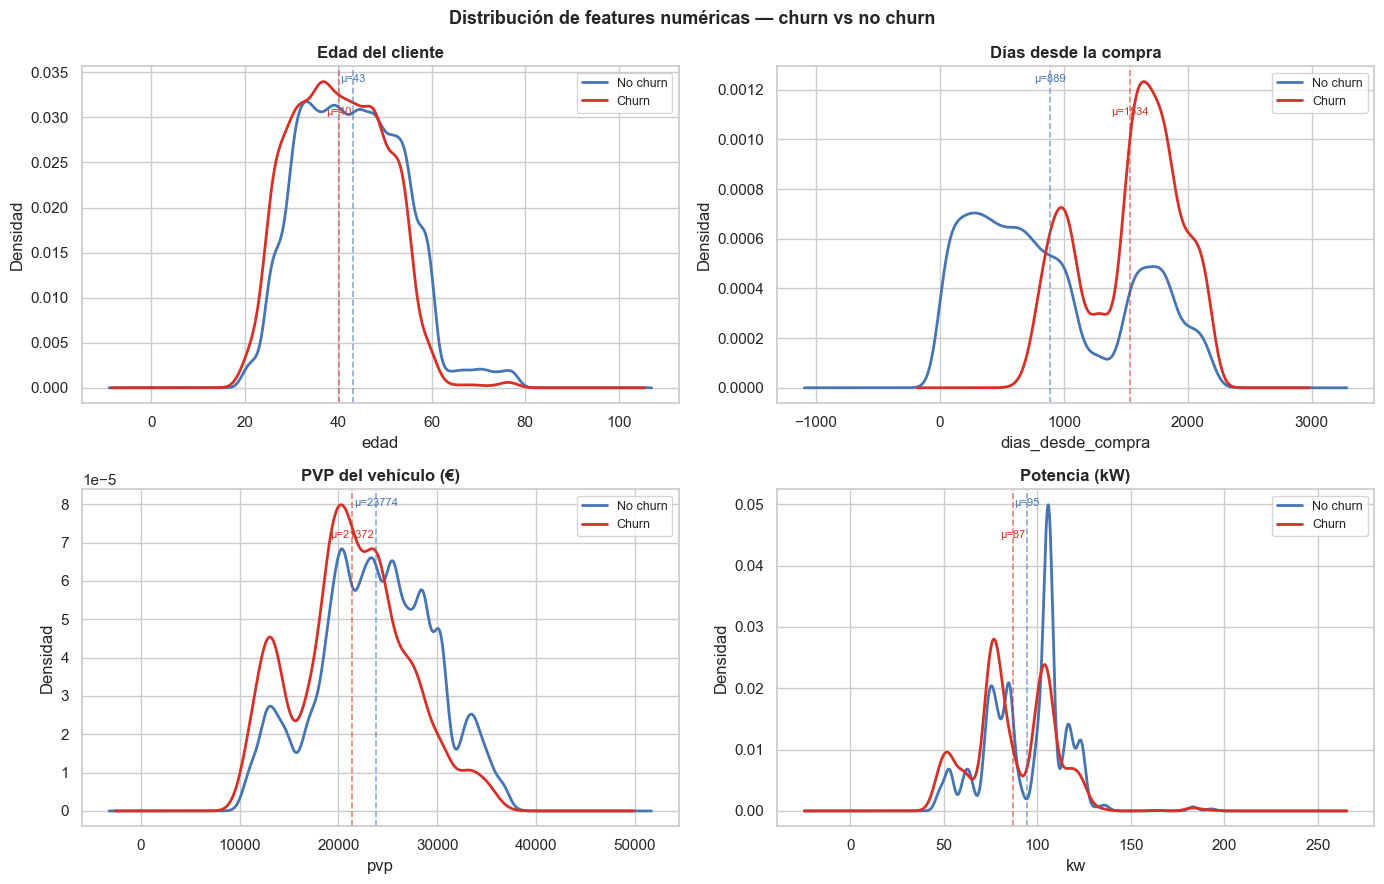

In [5]:
# ── Distribuciones numéricas: churn vs no churn ──────────────────────────────
num_plot = {
    'edad':                 'Edad del cliente',
    'dias_desde_compra':    'Días desde la compra',
    'pvp':                  'PVP del vehículo (€)',
    'kw':                   'Potencia (kW)',
}

churn0 = df[df['churn'] == 0]
churn1 = df[df['churn'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, title) in zip(axes.flat, num_plot.items()):
    # KDE
    churn0[col].plot.kde(ax=ax, label='No churn', color='#4575b4', linewidth=2)
    churn1[col].plot.kde(ax=ax, label='Churn',    color='#d73027', linewidth=2)
    
    # Vertical means
    ax.axvline(churn0[col].mean(), color='#4575b4', linestyle='--', alpha=0.6, linewidth=1.2)
    ax.axvline(churn1[col].mean(), color='#d73027', linestyle='--', alpha=0.6, linewidth=1.2)
    
    # Annotations
    ax.text(churn0[col].mean(), ax.get_ylim()[1] * 0.95,
            f'μ={churn0[col].mean():.0f}', color='#4575b4', ha='center', fontsize=8)
    ax.text(churn1[col].mean(), ax.get_ylim()[1] * 0.85,
            f'μ={churn1[col].mean():.0f}', color='#d73027', ha='center', fontsize=8)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features numéricas — churn vs no churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

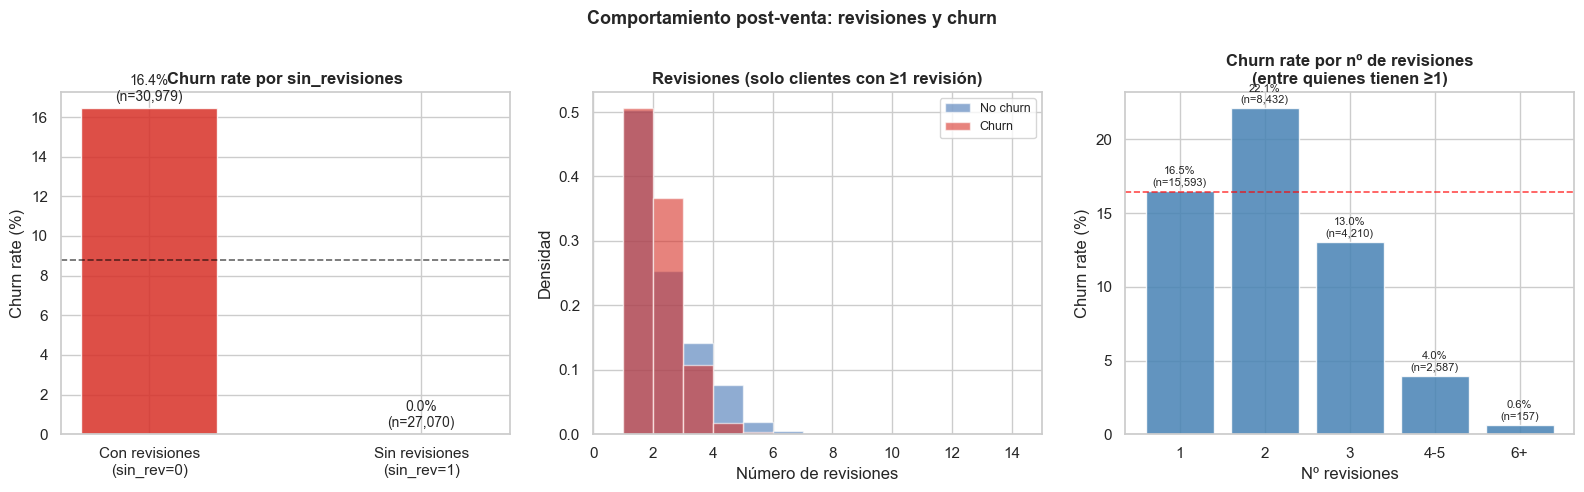

In [6]:
# ── Revisiones: sin_revisiones + distribución entre los que SÍ tienen ────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Churn rate: sin_revisiones
ax = axes[0]
cr_rev = df.groupby('sin_revisiones')['churn'].agg(['mean', 'count'])
labels = ['Con revisiones\n(sin_rev=0)', 'Sin revisiones\n(sin_rev=1)']
colors_bar = ['#d73027' if v > df['churn'].mean() else '#4575b4' for v in cr_rev['mean']]
bars = ax.bar(labels, cr_rev['mean'] * 100, color=colors_bar, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(df['churn'].mean() * 100, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
for bar, (_, row) in zip(bars, cr_rev.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=10)
ax.set_title('Churn rate por sin_revisiones', fontweight='bold')
ax.set_ylabel('Churn rate (%)')

# 2. Distribución de número de revisiones (solo clientes con revisiones > 0)
ax = axes[1]
has_rev = df[df['sin_revisiones'] == 0]
bins = range(0, int(has_rev['revisiones'].max()) + 2)
ax.hist(has_rev.loc[has_rev['churn']==0, 'revisiones'],
        bins=bins, density=True, alpha=0.6, color='#4575b4', label='No churn', edgecolor='white')
ax.hist(has_rev.loc[has_rev['churn']==1, 'revisiones'],
        bins=bins, density=True, alpha=0.6, color='#d73027', label='Churn',    edgecolor='white')
ax.set_title('Revisiones (solo clientes con ≥1 revisión)', fontweight='bold')
ax.set_xlabel('Número de revisiones'); ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
ax.set_xlim(0, 15)

# 3. Churn rate por número de revisiones (buckets)
ax = axes[2]
has_rev2 = df[df['sin_revisiones'] == 0].copy()
has_rev2['rev_bucket'] = pd.cut(has_rev2['revisiones'],
                                 bins=[0, 1, 2, 3, 5, 100],
                                 labels=['1', '2', '3', '4-5', '6+'],
                                 right=True)
cr_b = has_rev2.groupby('rev_bucket', observed=True)['churn'].agg(['mean','count'])
bars = ax.bar(cr_b.index.astype(str), cr_b['mean'] * 100,
              color='steelblue', alpha=0.85, edgecolor='white')
ax.axhline(has_rev2['churn'].mean() * 100, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
for bar, (_, row) in zip(bars, cr_b.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row["mean"]:.1%}\n(n={int(row["count"]):,})', ha='center', va='bottom', fontsize=8)
ax.set_title('Churn rate por nº de revisiones\n(entre quienes tienen ≥1)', fontweight='bold')
ax.set_xlabel('Nº revisiones'); ax.set_ylabel('Churn rate (%)')

plt.suptitle('Comportamiento post-venta: revisiones y churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# FILTRO OPCIONAL de antigüedad mínima
#
# Para scoring de ventas nuevas, este filtro suele generar shift extremo entre
# train y scoring. Por defecto queda desactivado.
# ══════════════════════════════════════════════════════════════════════════════

APLICAR_FILTRO_MIN_ANTIGUEDAD = False
MIN_DIAS = 600

if APLICAR_FILTRO_MIN_ANTIGUEDAD:
    n_antes = len(df)
    df = df[df['dias_desde_compra'] > MIN_DIAS].copy()
    print(f"Filtrado: {n_antes:,} → {len(df):,} filas  ({len(df)/n_antes:.1%} del original)")
    print(f"Churn rate post-filtro: {df['churn'].mean():.1%}")
else:
    print("Filtro de antigüedad: DESACTIVADO")

print(f"Dataset activo: {len(df):,} filas  |  Churn rate: {df['churn'].mean():.1%}")


Filtro de antigüedad: DESACTIVADO
Dataset activo: 58,049 filas  |  Churn rate: 8.8%


## 2. Split train / test

- 80% train / 20% test, estratificado por `churn`
- Split **antes** de cualquier preprocessing para evitar data leakage

In [8]:
ID_COLS = ['code', 'customer_id', 'sales_date', 'base_date']

X_all = df.drop(columns=['churn']).copy()
y_all = df['churn'].astype(int).copy()
groups_all = df['customer_id'].astype(str).copy()

# Split por cliente (evita leakage entre compras del mismo cliente)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_trainval, idx_test = next(gss_test.split(X_all, y_all, groups=groups_all))

X_trainval_raw = X_all.iloc[idx_trainval].reset_index(drop=True)
y_trainval = y_all.iloc[idx_trainval].reset_index(drop=True)
g_trainval = groups_all.iloc[idx_trainval].reset_index(drop=True)

X_test_raw = X_all.iloc[idx_test].reset_index(drop=True)
y_test = y_all.iloc[idx_test].reset_index(drop=True)
g_test = groups_all.iloc[idx_test].reset_index(drop=True)

# Sub-split train/validation para seleccionar umbral sin tocar test
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_train, idx_val = next(gss_val.split(X_trainval_raw, y_trainval, groups=g_trainval))

X_train_raw = X_trainval_raw.iloc[idx_train].reset_index(drop=True)
y_train = y_trainval.iloc[idx_train].reset_index(drop=True)
g_train = g_trainval.iloc[idx_train].reset_index(drop=True)

X_val_raw = X_trainval_raw.iloc[idx_val].reset_index(drop=True)
y_val = y_trainval.iloc[idx_val].reset_index(drop=True)
g_val = g_trainval.iloc[idx_val].reset_index(drop=True)

# Matrices de modelado (sin columnas de identificación)
X_train = X_train_raw.drop(columns=ID_COLS)
X_val = X_val_raw.drop(columns=ID_COLS)
X_test = X_test_raw.drop(columns=ID_COLS)

overlap_train_test = len(set(g_train.unique()) & set(g_test.unique()))
overlap_val_test = len(set(g_val.unique()) & set(g_test.unique()))

print(f"Train: {X_train.shape}  |  Positivos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Val:   {X_val.shape}    |  Positivos: {y_val.sum()} ({y_val.mean():.1%})")
print(f"Test:  {X_test.shape}   |  Positivos: {y_test.sum()} ({y_test.mean():.1%})")
print(f"Overlap clientes train-test: {overlap_train_test}")
print(f"Overlap clientes val-test:   {overlap_val_test}")

scale_pos_weight = float((y_train == 0).sum() / y_train.sum())
print(f"scale_pos_weight (para XGBoost): {scale_pos_weight:.2f}")


Train: (37132, 36)  |  Positivos: 3264 (8.8%)
Val:   (9282, 36)    |  Positivos: 781 (8.4%)
Test:  (11635, 36)   |  Positivos: 1048 (9.0%)
Overlap clientes train-test: 0
Overlap clientes val-test:   0
scale_pos_weight (para XGBoost): 10.38


## 3. Grupos de features

**Modelo prospectivo** (por defecto): solo features disponibles en el momento de la venta.  
Válido para scoring de clientes nuevos donde no hay historial de taller.

Las features comportamentales están **comentadas** — descoméntalas para volver al modelo retrospectivo (solo útil si el scoring tiene historial post-compra).

| Tipo | Features activas |
|---|---|
| **Numéricas** | pvp, margen_relativo, coste_venta_no_impuestos, edad, renta_media_estimada, kw |
| **Categóricas (OHE)** | forma_pago, genero |
| **Categóricas (ordinal)** | equipamiento |
| **Categóricas (muchas clases)** | status_social, modelo |
| **Flags binarios** | margen_eur_negativo, mantenimiento_gratuito, seguro_bateria_largo_plazo, ext_garantia_tiene, ext_garantia_financiera, renta_desconocida, es_electrico |
| ~~**[RETRO]** Comportamentales~~ | ~~dias_desde_compra, revisiones, en_garantia, sin_revisiones~~ |

In [9]:
# ── Feature set final (prospectivo + historial causal previo a la venta) ─────
#
# Criterio de inclusión: feature debe (a) estar disponible en el momento de la
# venta, (b) variar entre los clientes de scoring, y (c) no codificar el target.
#
# Excluidos explícitamente:
#   - days_last_service : leakage directo (define el target)
#   - en_garantia       : constante en scoring (todos=1, recién comprado)
#   - sin_revisiones    : constante en scoring (todos=1, cero revisiones)
#   - revisiones        : constante en scoring (todos=0)
#   - km_*              : constante en scoring (todos=0)
#   - dias_desde_compra : shift distribucional (0-90 en scoring, 0-2000 en train)
#   - garantia_dias_restantes : colineal con dias_desde_compra (corr=-1.0)
#   - encuesta_cliente_zona_taller : corr real ≈ 0, métrica de zona no individual
#   - fue_lead, lead_compra : <0.3pp diferencia de churn rate
#   - tiene_queja       : corr=-0.008, 57% NaN, sin señal
#   - zona              : spread 0.48pp dentro del ruido estadístico

# ── Numéricas ─────────────────────────────────────────────────────────────────
num_features = [
    'pvp', 'margen_relativo', 'coste_venta_no_impuestos',
    'edad', 'renta_media_estimada', 'kw',
    'frequency_total', 'tenure_days', 'ticket_avg',
    'service_interval_mean_days', 'service_interval_std_days',
]

# ── Categóricas ───────────────────────────────────────────────────────────────
cat_ohe_features     = ['forma_pago', 'genero']
cat_ordinal_features = ['equipamiento']
equipamiento_order   = [['Low', 'Mid', 'Mid-High', 'High']]
cat_many_features    = ['status_social']#, 'modelo']
cat_all_features     = cat_ohe_features + cat_ordinal_features + cat_many_features

# ── Flags binarios (contratados en el momento de la venta, varían en scoring) ─
binary_features = [
    'margen_eur_negativo',
    'mantenimiento_gratuito',      # churn 0.46% (=1) vs 9.91% (=0) — señal fuerte
    'ext_garantia_tiene',
    'ext_garantia_financiera',
    'seguro_bateria_largo_plazo',
    'renta_desconocida',
    'es_electrico',
]

print(f"Numéricas:      {len(num_features)}")
print(f"Categóricas:    {len(cat_all_features)}")
print(f"Flags binarios: {len(binary_features)}")
print(f"Total features: {len(num_features) + len(cat_all_features) + len(binary_features)}")

Numéricas:      11
Categóricas:    4
Flags binarios: 7
Total features: 22


## 4. Función de evaluación

Calcula ROC-AUC, PR-AUC y el **umbral óptimo** (maximiza F1) en la curva Precision-Recall.

In [10]:
def evaluate_model(name, model, X_val, y_val, X_te, y_te):
    """Selecciona umbral en validación y reporta métricas finales en test."""
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_te_proba = model.predict_proba(X_te)[:, 1]

    # Métricas de ranking
    roc_auc_val = roc_auc_score(y_val, y_val_proba)
    pr_auc_val = average_precision_score(y_val, y_val_proba)
    roc_auc_te = roc_auc_score(y_te, y_te_proba)
    pr_auc_te = average_precision_score(y_te, y_te_proba)

    # Umbral óptimo en VALIDACIÓN
    precision_arr, recall_arr, thresholds = precision_recall_curve(y_val, y_val_proba)
    f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)
    opt_idx = np.argmax(f1_arr[:-1])
    opt_threshold = float(thresholds[opt_idx])
    opt_f1_val = float(f1_arr[opt_idx])

    # Predicción final en TEST con umbral elegido en validación
    y_te_pred = (y_te_proba >= opt_threshold).astype(int)
    f1_te = float(f1_score(y_te, y_te_pred))

    return {
        'model': name,
        'roc_auc': roc_auc_te,
        'pr_auc': pr_auc_te,
        'roc_auc_val': roc_auc_val,
        'pr_auc_val': pr_auc_val,
        'opt_threshold': opt_threshold,
        'f1_opt': f1_te,
        'f1_val_opt': opt_f1_val,
        'y_proba': y_te_proba,
        'y_pred': y_te_pred,
    }

results = {}
print("evaluate_model definida.")


evaluate_model definida.


## 5. Logistic Regression — baseline interpretable

- `forma_pago`, `genero`, `status_social`, `modelo` → `OneHotEncoder(drop='first')`
- `equipamiento` → `OrdinalEncoder` (Low < Mid < Mid-High < High)
- Numéricas → `StandardScaler`
- Desbalanceo → `class_weight='balanced'`

In [11]:
lr_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_features),
    ('ohe', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), cat_ohe_features + cat_many_features),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ord', OrdinalEncoder(
            categories=equipamiento_order,
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )),
    ]), cat_ordinal_features),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ]), binary_features),
], remainder='drop')

lr_pipeline = Pipeline([
    ('prep', lr_preprocessor),
    ('clf',  LogisticRegression(
                 class_weight='balanced',
                 max_iter=2000,
                 random_state=42,
                 C=0.1,
             )),
])

print("Entrenando Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
results['lr'] = evaluate_model('Logistic Regression', lr_pipeline, X_val, y_val, X_test, y_test)
res = results['lr']
print(f"VAL PR-AUC: {res['pr_auc_val']:.4f} | TEST ROC-AUC: {res['roc_auc']:.4f} | TEST PR-AUC: {res['pr_auc']:.4f} | TEST F1: {res['f1_opt']:.4f} (umbral={res['opt_threshold']:.3f})")


Entrenando Logistic Regression...
VAL PR-AUC: 0.1880 | TEST ROC-AUC: 0.7573 | TEST PR-AUC: 0.2000 | TEST F1: 0.2890 (umbral=0.601)


## 6. Random Forest

- Todas las categóricas → `OrdinalEncoder`
- Numéricas → sin escalar (los árboles no lo necesitan)
- Desbalanceo → `class_weight='balanced'`

In [12]:
rf_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), cat_ohe_features + cat_many_features),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ord', OrdinalEncoder(
            categories=equipamiento_order,
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )),
    ]), cat_ordinal_features),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ]), binary_features),
], remainder='drop')

rf_pipeline = Pipeline([
    ('prep', rf_preprocessor),
    ('clf',  RandomForestClassifier(
                 n_estimators=300,
                 max_depth=10,
                 min_samples_leaf=10,
                 class_weight='balanced',
                 random_state=42,
                 n_jobs=-1,
             )),
])

print("Entrenando Random Forest...")
rf_pipeline.fit(X_train, y_train)
results['rf'] = evaluate_model('Random Forest', rf_pipeline, X_val, y_val, X_test, y_test)
res = results['rf']
print(f"VAL PR-AUC: {res['pr_auc_val']:.4f} | TEST ROC-AUC: {res['roc_auc']:.4f} | TEST PR-AUC: {res['pr_auc']:.4f} | TEST F1: {res['f1_opt']:.4f} (umbral={res['opt_threshold']:.3f})")


Entrenando Random Forest...
VAL PR-AUC: 0.1973 | TEST ROC-AUC: 0.7805 | TEST PR-AUC: 0.2134 | TEST F1: 0.3013 (umbral=0.651)


## 7. XGBoost

- Todas las categóricas → `OrdinalEncoder`
- Numéricas → sin escalar
- Desbalanceo → `scale_pos_weight = n_negativos / n_positivos`

In [13]:
xgb_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), cat_ohe_features + cat_many_features),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ord', OrdinalEncoder(
            categories=equipamiento_order,
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )),
    ]), cat_ordinal_features),
    ('bin', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ]), binary_features),
], remainder='drop')

xgb_pipeline = Pipeline([
    ('prep', xgb_preprocessor),
    ('clf',  XGBClassifier(
                 scale_pos_weight=scale_pos_weight,
                 n_estimators=300,
                 max_depth=6,
                 learning_rate=0.05,
                 subsample=0.8,
                 colsample_bytree=0.8,
                 random_state=42,
                 n_jobs=-1,
                 eval_metric='logloss',
                 verbosity=0,
             )),
])

print("Entrenando XGBoost...")
xgb_pipeline.fit(X_train, y_train)
results['xgb'] = evaluate_model('XGBoost', xgb_pipeline, X_val, y_val, X_test, y_test)
res = results['xgb']
print(f"VAL PR-AUC: {res['pr_auc_val']:.4f} | TEST ROC-AUC: {res['roc_auc']:.4f} | TEST PR-AUC: {res['pr_auc']:.4f} | TEST F1: {res['f1_opt']:.4f} (umbral={res['opt_threshold']:.3f})")


Entrenando XGBoost...
VAL PR-AUC: 0.1963 | TEST ROC-AUC: 0.7878 | TEST PR-AUC: 0.2242 | TEST F1: 0.3087 (umbral=0.572)


## 8. LightGBM

- Categóricas → `category` dtype (soporte nativo en LightGBM)
- Numéricas → sin escalar
- Desbalanceo → `is_unbalance=True`

In [14]:
def prep_lgbm(X):
    """Selecciona features activas y prepara dtype/category para LightGBM."""
    feature_cols = num_features + cat_all_features + binary_features
    X_out = X[feature_cols].copy()

    for col in num_features + binary_features:
        X_out[col] = pd.to_numeric(X_out[col], errors='coerce').fillna(0)

    for col in cat_all_features:
        X_out[col] = X_out[col].fillna('Sin_dato').astype('category')

    return X_out

X_train_lgbm = prep_lgbm(X_train)
X_val_lgbm   = prep_lgbm(X_val)
X_test_lgbm  = prep_lgbm(X_test)

lgbm_model = LGBMClassifier(
    is_unbalance=True,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

print("Entrenando LightGBM...")
lgbm_model.fit(X_train_lgbm, y_train)
results['lgbm'] = evaluate_model('LightGBM', lgbm_model, X_val_lgbm, y_val, X_test_lgbm, y_test)
res = results['lgbm']
print(f"VAL PR-AUC: {res['pr_auc_val']:.4f} | TEST ROC-AUC: {res['roc_auc']:.4f} | TEST PR-AUC: {res['pr_auc']:.4f} | TEST F1: {res['f1_opt']:.4f} (umbral={res['opt_threshold']:.3f})")


Entrenando LightGBM...
VAL PR-AUC: 0.1969 | TEST ROC-AUC: 0.7867 | TEST PR-AUC: 0.2281 | TEST F1: 0.3084 (umbral=0.597)


## 9. Comparación de modelos

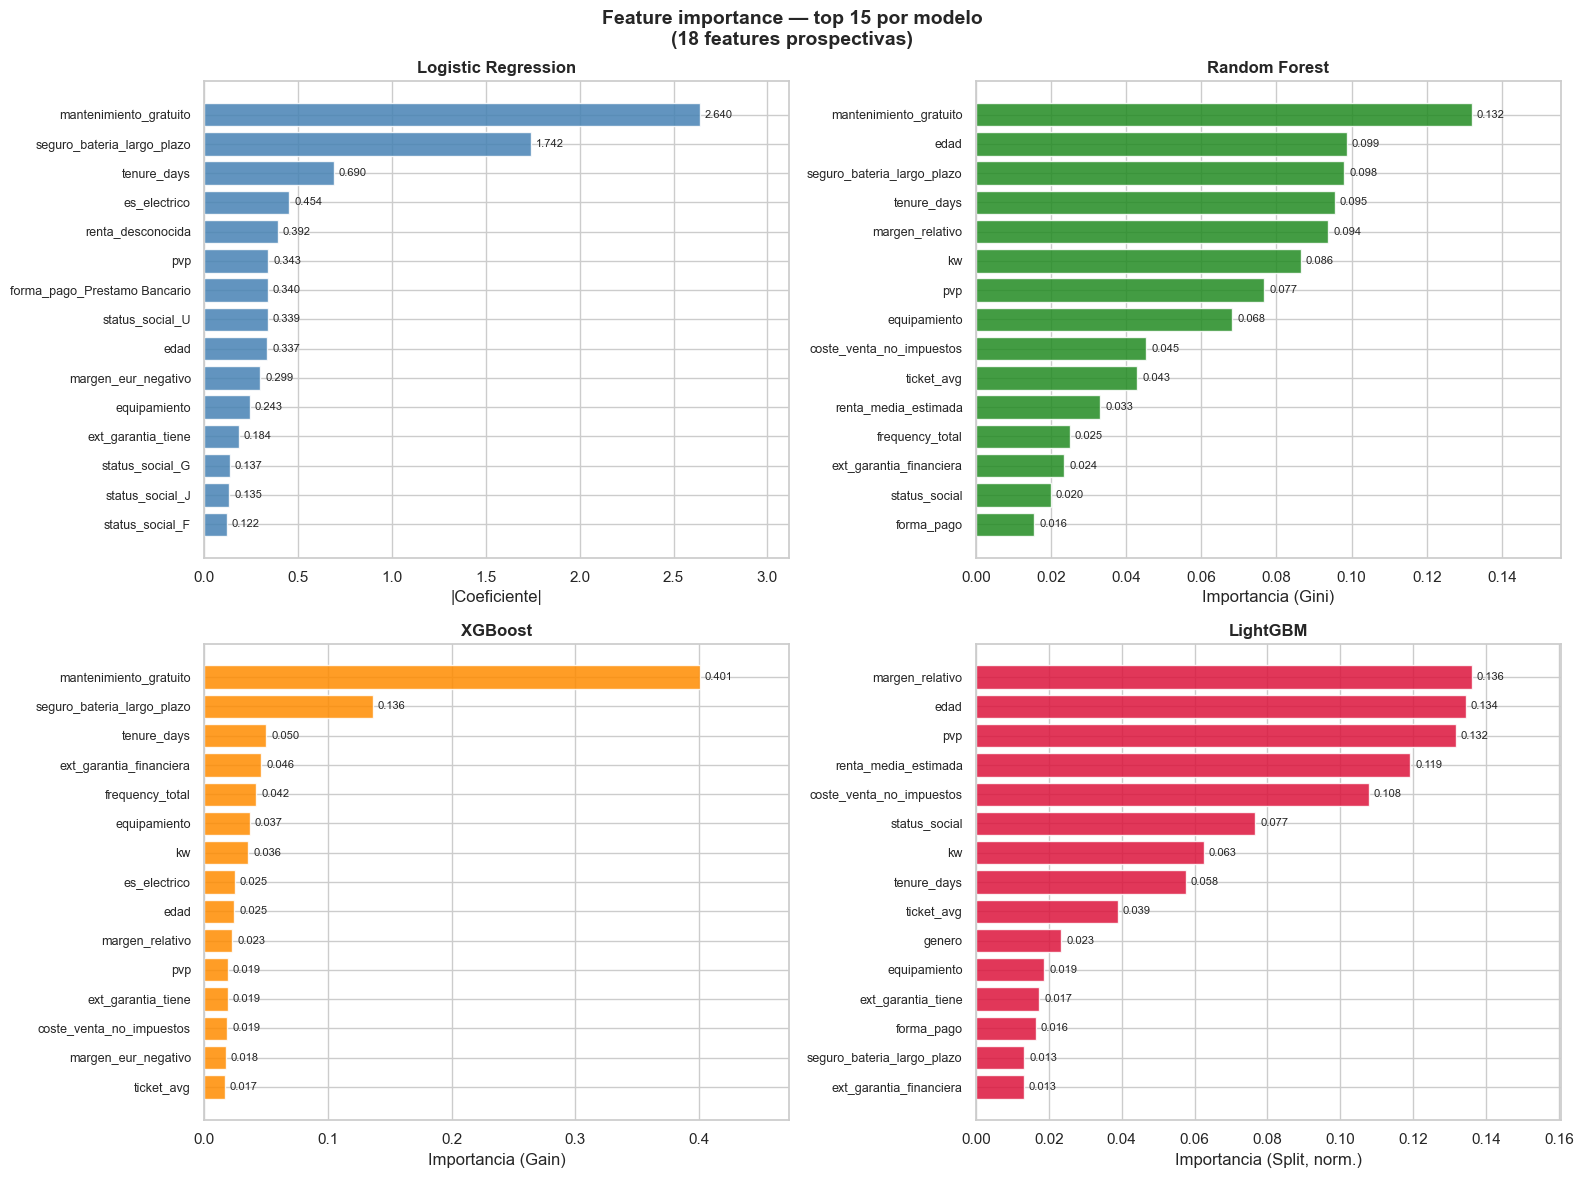

In [15]:
# ── Feature importance — top 15 por modelo ────────────────────────────────────

# Nombres de features según el orden que produce cada ColumnTransformer
# RF / XGB:  num → (cat_ohe + cat_many) → cat_ordinal → binary
feat_names_tree = num_features + cat_ohe_features + cat_many_features + cat_ordinal_features + binary_features

# LGBM:  num → cat_all (ohe + ordinal + many) → binary
feat_names_lgbm = num_features + cat_all_features + binary_features

# LR: get_feature_names_out() devuelve nombres con prefijo 'transformer__feature'
feat_names_lr_raw = lr_pipeline.named_steps['prep'].get_feature_names_out()
feat_names_lr = [n.split('__', 1)[1] if '__' in n else n for n in feat_names_lr_raw]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

configs = [
    ('lr',   'Logistic Regression', feat_names_lr,   np.abs(lr_pipeline.named_steps['clf'].coef_[0]),              'steelblue',    '|Coeficiente|'),
    ('rf',   'Random Forest',       feat_names_tree, rf_pipeline.named_steps['clf'].feature_importances_,          'forestgreen',  'Importancia (Gini)'),
    ('xgb',  'XGBoost',             feat_names_tree, xgb_pipeline.named_steps['clf'].feature_importances_,         'darkorange',   'Importancia (Gain)'),
    ('lgbm', 'LightGBM',            feat_names_lgbm, lgbm_model.feature_importances_ / lgbm_model.feature_importances_.sum(), 'crimson', 'Importancia (Split, norm.)'),
]

for ax, (key, title, names, values, color, xlabel) in zip(axes.flat, configs):
    fi = (
        pd.Series(values, index=names)
        .sort_values(ascending=False)
        .head(15)
        .sort_values(ascending=True)   # invertir para barh
    )
    bars = ax.barh(fi.index, fi.values, color=color, alpha=0.85, edgecolor='white')

    # Etiqueta de valor en cada barra
    for bar, val in zip(bars, fi.values):
        ax.text(bar.get_width() + fi.values.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, fi.values.max() * 1.18)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature importance — top 15 por modelo\n(18 features prospectivas)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
summary = pd.DataFrame([
    {
        'Modelo': v['model'],
        'VAL ROC-AUC': round(v['roc_auc_val'], 4),
        'VAL PR-AUC': round(v['pr_auc_val'], 4),
        'TEST ROC-AUC': round(v['roc_auc'], 4),
        'TEST PR-AUC': round(v['pr_auc'], 4),
        'TEST F1 (thr val)': round(v['f1_opt'], 4),
        'Umbral (val)': round(v['opt_threshold'], 3),
    }
    for v in results.values()
]).sort_values('VAL PR-AUC', ascending=False).reset_index(drop=True)

summary.style     .format({
        'VAL ROC-AUC': '{:.4f}', 'VAL PR-AUC': '{:.4f}',
        'TEST ROC-AUC': '{:.4f}', 'TEST PR-AUC': '{:.4f}',
        'TEST F1 (thr val)': '{:.4f}', 'Umbral (val)': '{:.3f}'
    })     .highlight_max(subset=['VAL PR-AUC', 'TEST ROC-AUC', 'TEST PR-AUC', 'TEST F1 (thr val)'], color='#c6efce')


,Modelo,VAL ROC-AUC,VAL PR-AUC,TEST ROC-AUC,TEST PR-AUC,TEST F1 (thr val),Umbral (val)
0,Random Forest,0.7776,0.1973,0.7805,0.2134,0.3013,0.651
1,LightGBM,0.7795,0.1969,0.7867,0.2281,0.3084,0.597
2,XGBoost,0.7812,0.1963,0.7878,0.2242,0.3087,0.572
3,Logistic Regression,0.7577,0.1880,0.7573,0.2000,0.2890,0.601


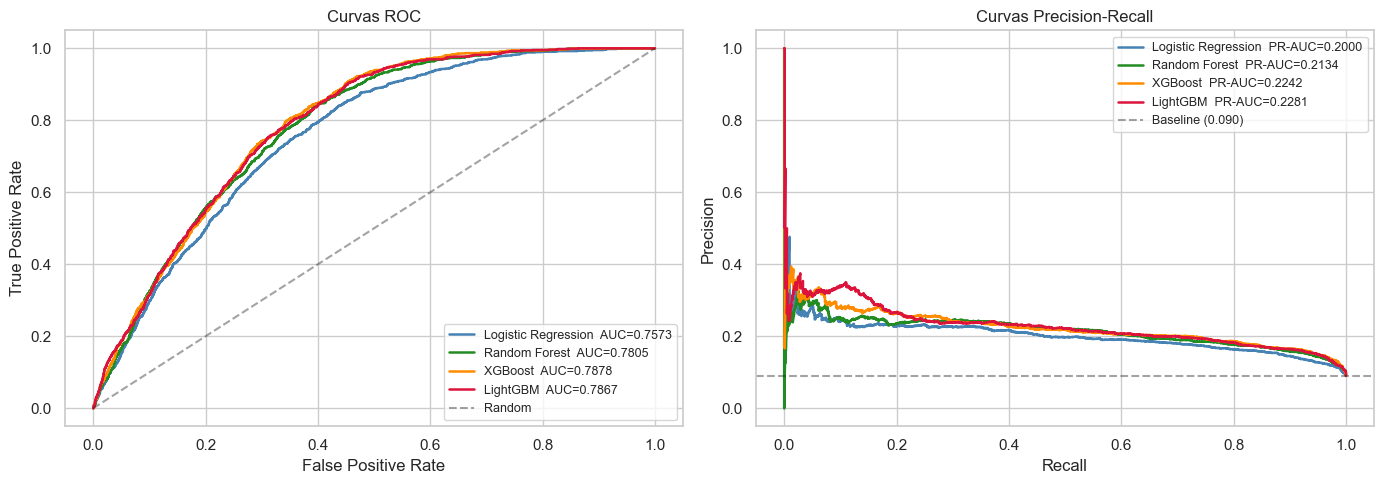

In [17]:
colors = {
    'lr':   'steelblue',
    'rf':   'forestgreen',
    'xgb':  'darkorange',
    'lgbm': 'crimson',
}

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC ──────────────────────────────────────────────────────────────────────
for key, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax_roc.plot(fpr, tpr, label=f"{res['model']}  AUC={res['roc_auc']:.4f}", color=colors[key], lw=1.8)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Curvas ROC')
ax_roc.legend(loc='lower right', fontsize=9)

# ── PR ───────────────────────────────────────────────────────────────────────
for key, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax_pr.plot(rec, prec, label=f"{res['model']}  PR-AUC={res['pr_auc']:.4f}", color=colors[key], lw=1.8)
baseline = y_test.mean()
ax_pr.axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f'Baseline ({baseline:.3f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Curvas Precision-Recall')
ax_pr.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('data/warehouse/curvas_modelos_claude.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análisis del modelo ganador

Matrices de confusión en el umbral óptimo (máximo F1 en curva PR).

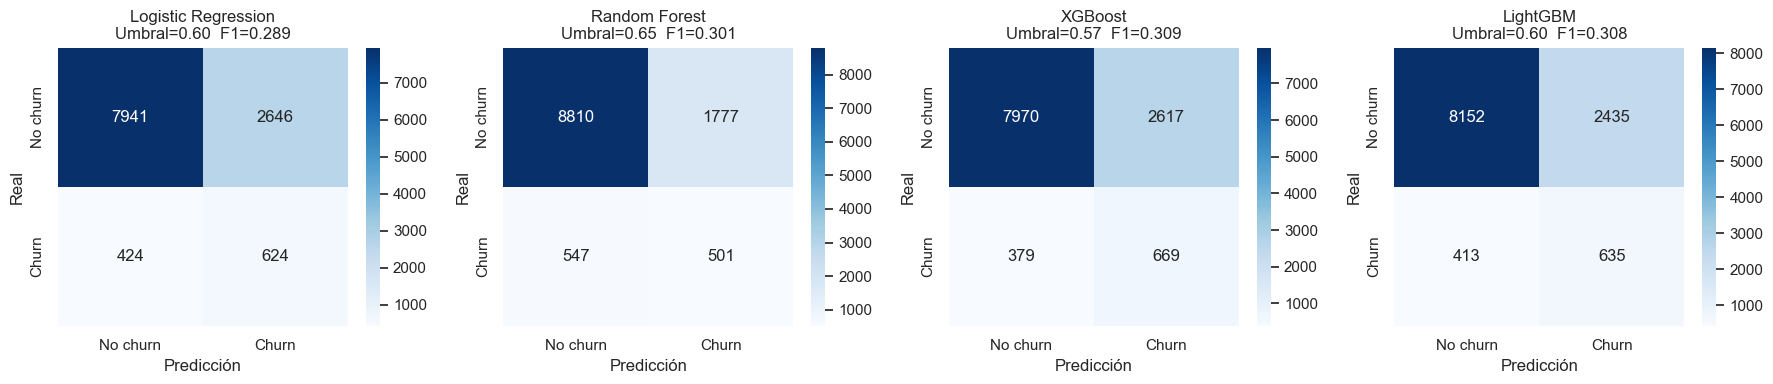

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (key, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No churn', 'Churn'],
                yticklabels=['No churn', 'Churn'])
    ax.set_title(f"{res['model']}\nUmbral={res['opt_threshold']:.2f}  F1={res['f1_opt']:.3f}")
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

In [19]:
# Selección por validación (sin tocar test para escoger modelo/umbral)
best_key = max(results, key=lambda k: results[k]['pr_auc_val'])
best = results[best_key]

print(f"Modelo ganador (según VAL PR-AUC): {best['model']}")
print(f"VAL ROC-AUC: {best['roc_auc_val']:.4f}  |  VAL PR-AUC: {best['pr_auc_val']:.4f}")
print(f"TEST ROC-AUC: {best['roc_auc']:.4f}  |  TEST PR-AUC: {best['pr_auc']:.4f}")
print(f"Umbral elegido en val: {best['opt_threshold']:.3f}")
print()
print(classification_report(y_test, best['y_pred'], target_names=['No churn', 'Churn']))


Modelo ganador (según VAL PR-AUC): Random Forest
VAL ROC-AUC: 0.7776  |  VAL PR-AUC: 0.1973
TEST ROC-AUC: 0.7805  |  TEST PR-AUC: 0.2134
Umbral elegido en val: 0.651

              precision    recall  f1-score   support

    No churn       0.94      0.83      0.88     10587
       Churn       0.22      0.48      0.30      1048

    accuracy                           0.80     11635
   macro avg       0.58      0.66      0.59     11635
weighted avg       0.88      0.80      0.83     11635



## 11. Predicciones sobre scoring.csv

Aplicamos el modelo ganador al conjunto de scoring y guardamos las predicciones.

In [20]:
scoring = pd.read_csv("data/warehouse/scoring_claude.csv", parse_dates=['sales_date', 'base_date'])
print(f"Scoring shape: {scoring.shape}")
scoring.head(3)

Scoring shape: (10000, 40)


,code,customer_id,sales_date,base_date,pvp,margen_relativo,margen_eur_negativo,coste_venta_no_impuestos,forma_pago,dias_desde_compra,...,edad,genero,renta_media_estimada,renta_desconocida,status_social,modelo,equipamiento,es_electrico,kw,zona
0,SYN009876,98788,2024-01-09,2023-12-31,32916.0,0.253105,0,0.0,Contado,-9,...,42,M,28175.0,0,G,I,Mid-High,0,106.0,CENTRO
1,SYN004421,45710,2024-02-09,2023-12-31,30388.0,0.203704,0,1482.0,Financiera Marca,-40,...,22,F,37630.0,0,A,I,High,0,106.0,ESTE
2,SYN008347,69631,2024-01-09,2023-12-31,14814.0,0.014955,0,1635.0,Financiera Marca,-9,...,48,M,21332.0,0,I,I,High,0,117.0,CENTRO


In [21]:
X_scoring = scoring.drop(columns=ID_COLS, errors='ignore')

# Si el modelo ganador es LightGBM necesita preprocessing especial
if best_key == 'lgbm':
    X_scoring_proc = prep_lgbm(X_scoring)
    scoring_proba  = lgbm_model.predict_proba(X_scoring_proc)[:, 1]
else:
    model_map     = {'lr': lr_pipeline, 'rf': rf_pipeline, 'xgb': xgb_pipeline}
    scoring_proba = model_map[best_key].predict_proba(X_scoring)[:, 1]

scoring_pred = (scoring_proba >= best['opt_threshold']).astype(int)

print(f"Registros en scoring: {len(scoring):,}")
print(f"Churn predicho: {scoring_pred.sum():,}  ({scoring_pred.mean():.1%})")


Registros en scoring: 10,000
Churn predicho: 833  (8.3%)


In [22]:
output = scoring[['code']].copy()
output['churn_proba'] = scoring_proba.round(4)
output['churn_pred'] = scoring_pred

out_path = "data/warehouse/predictions_claude.csv"
output.to_csv(out_path, index=False)
print(f"Predicciones guardadas en: {out_path}")
print(output[output['churn_pred'] == 1])
output.head(10)

Predicciones guardadas en: data/warehouse/predictions_claude.csv
           code  churn_proba  churn_pred
1162  SYN003532       0.6519           1
1502  SYN000002       0.7043           1
1510  SYN000012       0.6897           1
1521  SYN000026       0.7333           1
1522  SYN000027       0.7137           1
...         ...          ...         ...
9961  SYN009956       0.7113           1
9963  SYN009958       0.6925           1
9980  SYN009978       0.6523           1
9983  SYN009981       0.6603           1
9990  SYN009989       0.6647           1

[833 rows x 3 columns]


,code,churn_proba,churn_pred
0,SYN009876,0.0527,0
1,SYN004421,0.0260,0
2,SYN008347,0.1254,0
3,SYN001098,0.1259,0
4,SYN002408,0.3966,0
5,SYN009885,0.2524,0
6,SYN006662,0.2646,0
7,SYN003182,0.1836,0
8,SYN006264,0.0675,0
9,SYN009066,0.0388,0


### Estructura de las predicciones

Sin etiqueta real, usamos `churn_proba` y `churn_pred` para entender cómo se distribuyen las predicciones sobre la población de scoring.

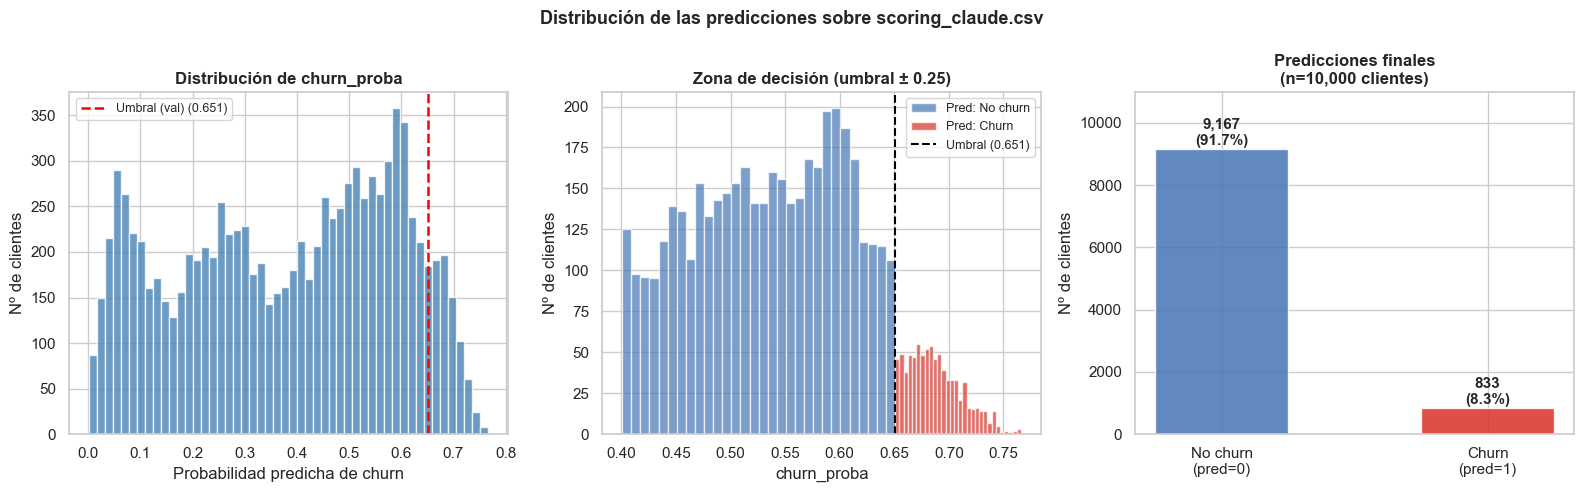

In [23]:
# ── Distribución de probabilidades predichas ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histograma de churn_proba
ax = axes[0]
ax.hist(output['churn_proba'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(best['opt_threshold'], color='red', linestyle='--', linewidth=1.8,
           label=f'Umbral (val) ({best["opt_threshold"]:.3f})')
ax.set_xlabel('Probabilidad predicha de churn')
ax.set_ylabel('Nº de clientes')
ax.set_title('Distribución de churn_proba', fontweight='bold')
ax.legend(fontsize=9)

# 2. Zoom en la zona de decisión (umbral ± 0.25)
ax = axes[1]
t = best['opt_threshold']
zona = output[(output['churn_proba'] >= max(0, t - 0.25)) &
              (output['churn_proba'] <= min(1, t + 0.25))]
ax.hist(zona.loc[zona['churn_pred']==0, 'churn_proba'],
        bins=30, color='#4575b4', alpha=0.7, label='Pred: No churn', edgecolor='white')
ax.hist(zona.loc[zona['churn_pred']==1, 'churn_proba'],
        bins=30, color='#d73027', alpha=0.7, label='Pred: Churn',    edgecolor='white')
ax.axvline(t, color='black', linestyle='--', linewidth=1.5, label=f'Umbral ({t:.3f})')
ax.set_xlabel('churn_proba'); ax.set_ylabel('Nº de clientes')
ax.set_title('Zona de decisión (umbral ± 0.25)', fontweight='bold')
ax.legend(fontsize=9)

# 3. Conteo predicho churn vs no churn
ax = axes[2]
counts = output['churn_pred'].value_counts().sort_index()
labels = ['No churn\n(pred=0)', 'Churn\n(pred=1)']
colors_pie = ['#4575b4', '#d73027']
bars = ax.bar(labels, counts.values, color=colors_pie, alpha=0.85, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    pct = count / len(output) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Nº de clientes')
ax.set_title(f'Predicciones finales\n(n={len(output):,} clientes)', fontweight='bold')
ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Distribución de las predicciones sobre scoring_claude.csv', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

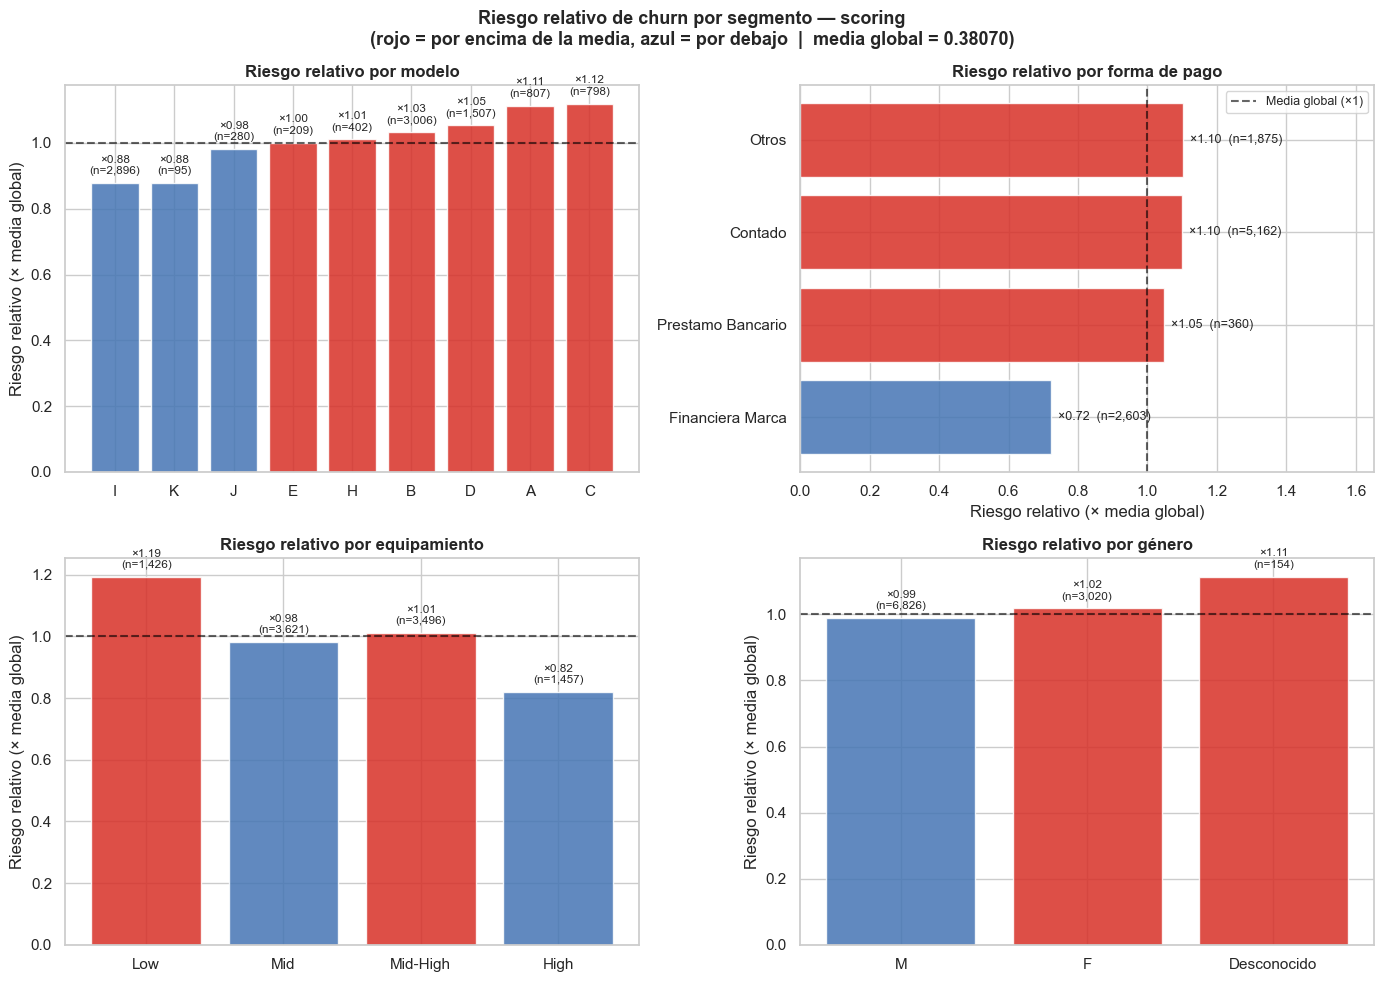

In [24]:
# ── Riesgo relativo de churn por segmento (scoring) ──────────────────────────                                                                                                                                                                                                                                
# churn_proba absoluta es ~0 para todos (clientes sin 400 días aún).
# El riesgo RELATIVO (grupo / media global) sí revela la estructura del modelo.                                                                                                                                                                                                                                
                                                                                                                                                                                                                                                                                                            
sc = output.merge(scoring.drop(columns=['code']), left_index=True, right_index=True)

global_mean = sc['churn_proba'].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, title) in zip(axes.flat, [
    ('modelo',       'Riesgo relativo por modelo'),
    ('forma_pago',   'Riesgo relativo por forma de pago'),
    ('equipamiento', 'Riesgo relativo por equipamiento'),
    ('genero',       'Riesgo relativo por género'),
]):
    if col == 'equipamiento':
        order = ['Low', 'Mid', 'Mid-High', 'High']
        cr  = sc.groupby(col)['churn_proba'].mean().reindex(order)
        cnt = sc.groupby(col)['churn_pred'].agg(['sum', 'count']).reindex(order)
    else:
        cr  = sc.groupby(col)['churn_proba'].mean().sort_values()
        cnt = sc.groupby(col)['churn_pred'].agg(['sum', 'count']).reindex(cr.index)

    rr = cr / global_mean  # riesgo relativo (1.0 = media global)
    colors_bar = ['#d73027' if v > 1 else '#4575b4' for v in rr.values]

    if col == 'forma_pago':
        bars = ax.barh(rr.index, rr.values, color=colors_bar, alpha=0.85, edgecolor='white')
        ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Media global (×1)')
        for bar, (idx, row) in zip(bars, cnt.iterrows()):
            ax.text(bar.get_width() + 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    f'×{bar.get_width():.2f}  (n={int(row["count"]):,})',
                    va='center', fontsize=9)
        ax.set_xlim(0, rr.max() * 1.5)
        ax.set_xlabel('Riesgo relativo (× media global)')
        ax.legend(fontsize=9)
    else:
        bars = ax.bar(rr.index, rr.values, color=colors_bar, alpha=0.85, edgecolor='white')
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        for bar, (idx, row) in zip(bars, cnt.iterrows()):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f'×{bar.get_height():.2f}\n(n={int(row["count"]):,})',
                    ha='center', va='bottom', fontsize=8.5)
        ax.set_ylabel('Riesgo relativo (× media global)')

    ax.set_title(title, fontweight='bold')

plt.suptitle(
    f'Riesgo relativo de churn por segmento — scoring\n'
    f'(rojo = por encima de la media, azul = por debajo  |  media global = {global_mean:.5f})',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/wm/9zl_s0kn46n56k_vcfy7q0cc0000gn/T/ipykernel_27476/774961026.py:35: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/UAX-IA/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


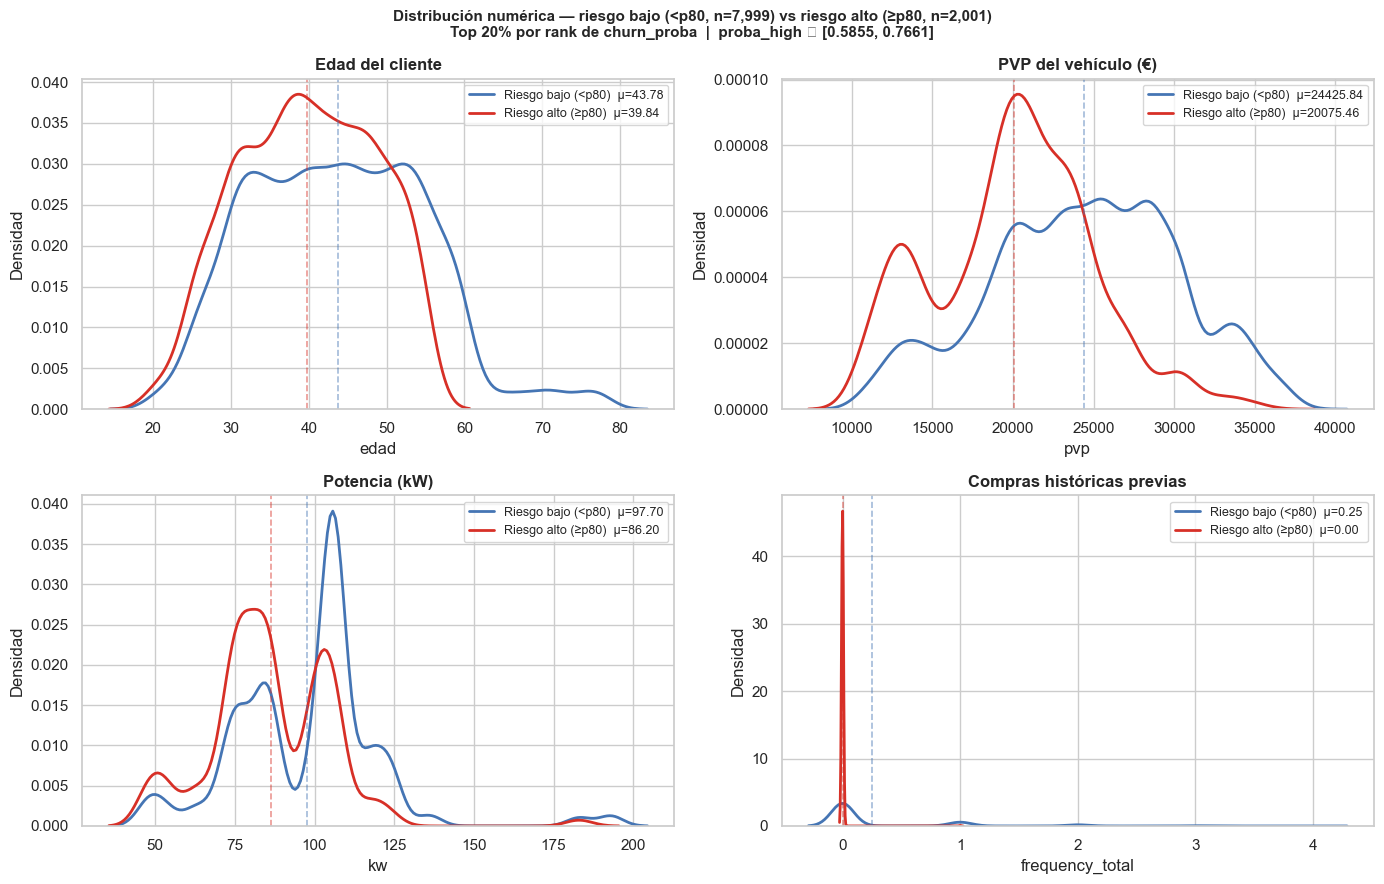

In [25]:
# ── Distribución numérica por nivel de riesgo predicho ───────────────────────
# Split por rank percentil de churn_proba: top 20% vs bottom 80%

sc['proba_rank'] = sc['churn_proba'].rank(pct=True, method='first')
risk_high = sc[sc['proba_rank'] >= 0.80]
risk_low  = sc[sc['proba_rank'] <  0.80]

num_plot = {
    'edad': 'Edad del cliente',
    'pvp': 'PVP del vehículo (€)',
    'kw': 'Potencia (kW)',
    'frequency_total': 'Compras históricas previas',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, title) in zip(axes.flat, num_plot.items()):
    sns.kdeplot(data=risk_low,  x=col, ax=ax, color='#4575b4', linewidth=2,
                label=f'Riesgo bajo (<p80)  μ={risk_low[col].mean():.2f}',
                warn_singular=False)
    sns.kdeplot(data=risk_high, x=col, ax=ax, color='#d73027', linewidth=2,
                label=f'Riesgo alto (≥p80)  μ={risk_high[col].mean():.2f}',
                warn_singular=False)
    ax.axvline(risk_low[col].mean(),  color='#4575b4', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.axvline(risk_high[col].mean(), color='#d73027', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

title_line1 = (f'Distribución numérica — riesgo bajo (<p80, n={len(risk_low):,})'
               f' vs riesgo alto (≥p80, n={len(risk_high):,})')
title_line2 = (f'Top 20% por rank de churn_proba  |  '
               f'proba_high ∈ [{risk_high["churn_proba"].min():.4f}, {risk_high["churn_proba"].max():.4f}]')
plt.suptitle(f'{title_line1}\n{title_line2}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()